Imports

In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


Reading the data from the data folder. It is sourced from Fangraphs and includes a row for each season/player from 2015-2025 with potential features of WAR

In [40]:
df = pd.read_csv('data/WAR Predictor 15-25.csv')

Printing out the data

In [41]:
df.head()

,Season,Name,Team,PA,WAR,BB%,K%,Barrel%,HardHit%,EV,...,LD%,GB%,FB%,Pull%,Cent%,Oppo%,Spd,NameASCII,PlayerId,MLBAMID
0,2025,Oneil Cruz,PIT,544,1.580288,0.117647,0.319853,0.178808,0.566225,95.835664,...,0.145695,0.480132,0.374172,0.407285,0.384106,0.208609,7.068212,Oneil Cruz,21711,665833
1,2017,Giancarlo Stanton,MIA,692,6.434607,0.122832,0.235549,0.173913,0.457666,92.009653,...,0.160183,0.446224,0.393593,0.446224,0.352403,0.201373,2.259233,Giancarlo Stanton,4949,519317
2,2021,Giancarlo Stanton,NYY,579,3.050541,0.108808,0.271157,0.157303,0.556180,95.100852,...,0.185393,0.446629,0.367978,0.379213,0.339888,0.280899,0.603186,Giancarlo Stanton,4949,519317
3,2018,Giancarlo Stanton,NYY,705,3.772407,0.099291,0.299291,0.151442,0.507212,93.694444,...,0.185096,0.449519,0.365385,0.389423,0.370192,0.240385,3.768260,Giancarlo Stanton,4949,519317
4,2024,Oneil Cruz,PIT,599,3.603457,0.085142,0.302170,0.156593,0.549451,95.480663,...,0.184066,0.478022,0.337912,0.420330,0.329670,0.250000,6.152637,Oneil Cruz,21711,665833


Since the 2020 season was shortened, we are removing it from our model so we are not training WAR which is compounding on partial data

In [42]:
# removing the shortened 2020 season
df = df[df['Season'] != 2020]

In [43]:
df.columns

Index(['Season', 'Name', 'Team', 'PA', 'WAR', 'BB%', 'K%', 'Barrel%',
       'HardHit%', 'EV', 'LA', 'maxEV', 'BABIP', 'LD%', 'GB%', 'FB%', 'Pull%',
       'Cent%', 'Oppo%', 'Spd', 'NameASCII', 'PlayerId', 'MLBAMID'],
      dtype='object')

Dropping some of the unneeded columns such as Name and Team and splitting out WAR into a seperate y df

In [44]:
y = df['WAR']
x = df.drop(['Season', 'PA', 'WAR', 'Name', 'Team', 'NameASCII', 'PlayerId', 'MLBAMID'], axis=1)

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [46]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [47]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')


Mean Squared Error: 1.4119876789180352
R^2 Score: 0.66130017599024


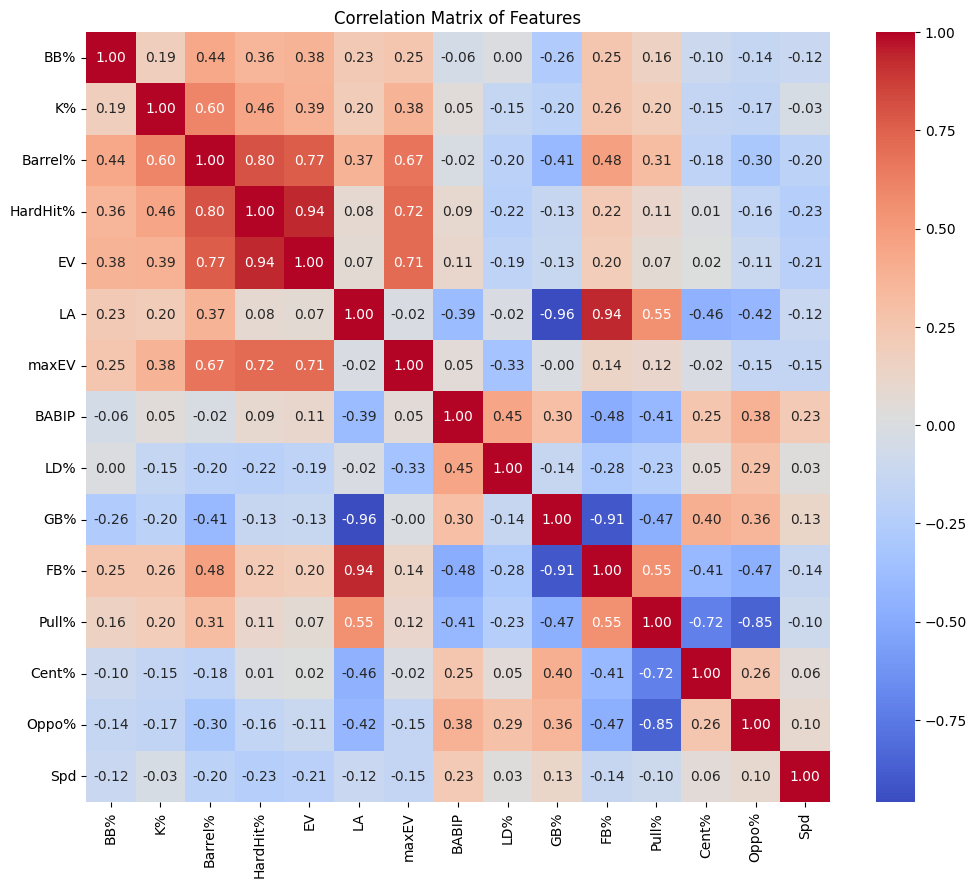

In [48]:
# correlation matrix 
plt.figure(figsize=(12, 10))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [57]:
# removing redudant features based on the correlation matrix and feature importance

# print the most important features
print(coeffs.sort_values(ascending=False).head(15))
# removing features with low importance and high correlation
x = x.drop(['Cent%', 'HardHit%', 'maxEV', 'FB%'], axis=1)

Pull%       5.347258e+06
Oppo%       5.347254e+06
Cent%       5.347251e+06
BABIP       3.453304e+01
Barrel%     2.066325e+01
BB%         1.460599e+01
HardHit%    1.041132e+00
Spd         3.905401e-01
EV          3.905103e-02
maxEV      -2.807268e-02
LA         -2.822622e-02
K%         -2.025082e+01
FB%        -1.171506e+07
GB%        -1.171506e+07
LD%        -1.171507e+07
dtype: float64


In [58]:
# re-running the model with the reduced features
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
reduced_model = LinearRegression()
reduced_model.fit(x_train, y_train)
y_pred_reduced = reduced_model.predict(x_test)
mse_reduced = mean_squared_error(y_test, y_pred_reduced)
print(f'Mean Squared Error (Reduced): {mse_reduced}')
r2_reduced = r2_score(y_test, y_pred_reduced)
print(f'R^2 Score (Reduced): {r2_reduced}')

Mean Squared Error (Reduced): 1.4125783867702468
R^2 Score (Reduced): 0.6611584802456012


In [59]:
# printing the coefficients of the reduced model
coeffs_reduced = pd.Series(model.coef_, index=x.columns)
print(coeffs_reduced.sort_values(ascending=False).head(15))

BABIP      34.420389
Barrel%    20.192592
BB%        14.672540
Pull%       7.649835
Oppo%       2.810768
Spd         0.390388
EV          0.052993
LA         -0.022343
GB%        -8.230894
LD%       -11.482229
K%        -20.196049
dtype: float64


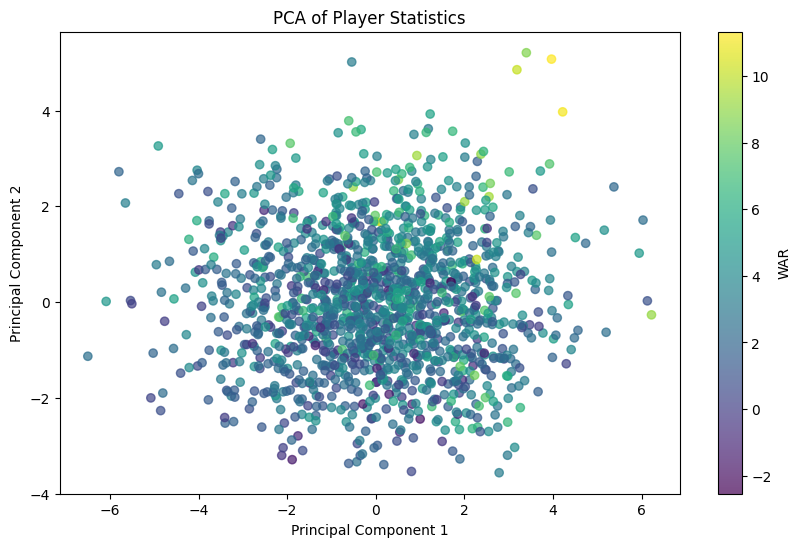

In [64]:
# principal component analysis
x_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(label='WAR')
plt.title('PCA of Player Statistics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [66]:
# most important features from PCA
pca_components = pd.DataFrame(pca.components_, columns=x.columns)
print(pca_components)
print(pca.explained_variance_ratio_)

        BB%        K%   Barrel%        EV        LA     BABIP       LD%  \
0  0.231239  0.243589  0.373510  0.235124  0.402355 -0.236996 -0.150049   
1  0.267693  0.349557  0.422356  0.519165 -0.202328  0.392242  0.062552   

        GB%     Pull%     Oppo%       Spd  
0 -0.385045  0.390270 -0.362513 -0.140858  
1  0.136373 -0.275283  0.249807 -0.052426  
[0.34150846 0.18252902]


In [81]:
# trying a random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42
)
rf_model.fit(x_train, y_train)
rf_y_pred = rf_model.predict(x_test)
rf_mse = mean_squared_error(y_test, rf_y_pred)
print(f'Random Forest Mean Squared Error: {rf_mse}')
rf_r2 = r2_score(y_test, rf_y_pred)
print(f'Random Forest R^2 Score: {rf_r2}')

Random Forest Mean Squared Error: 1.983247496691626
Random Forest R^2 Score: 0.5242695186887365


In [82]:
print(rf_model.score(x_test, y_test))
print(rf_model.score(x_train, y_train))

0.5242695186887365
0.6920315787559461


In [84]:
# predicting WAR for next season based on the current season's stats
next_season_pred = rf_model.predict(x)
df['Predicted_WAR'] = next_season_pred
print(df[['Name', 'Season', 'WAR', 'Predicted_WAR']].head(20))

                     Name  Season       WAR  Predicted_WAR
0              Oneil Cruz    2025  1.580288       3.167285
1       Giancarlo Stanton    2017  6.434607       4.045099
2       Giancarlo Stanton    2021  3.050541       3.704017
3       Giancarlo Stanton    2018  3.772407       3.954200
4              Oneil Cruz    2024  3.603457       4.680109
5        Ronald Acuña Jr.    2023  9.154090       8.108074
6             Aaron Judge    2017  8.695028       8.620988
7   Vladimir Guerrero Jr.    2025  3.887598       4.076973
8           Shohei Ohtani    2025  7.480309       5.844974
9           Manny Machado    2021  4.476650       4.290795
10            Ketel Marte    2025  4.597193       4.132698
11          Shohei Ohtani    2024  8.951945       8.078579
12          Shohei Ohtani    2022  3.611544       4.158523
13            Nelson Cruz    2015  5.032418       4.666688
14            Aaron Judge    2021  5.489977       4.759369
15          Shohei Ohtani    2021  5.018949       4.6010

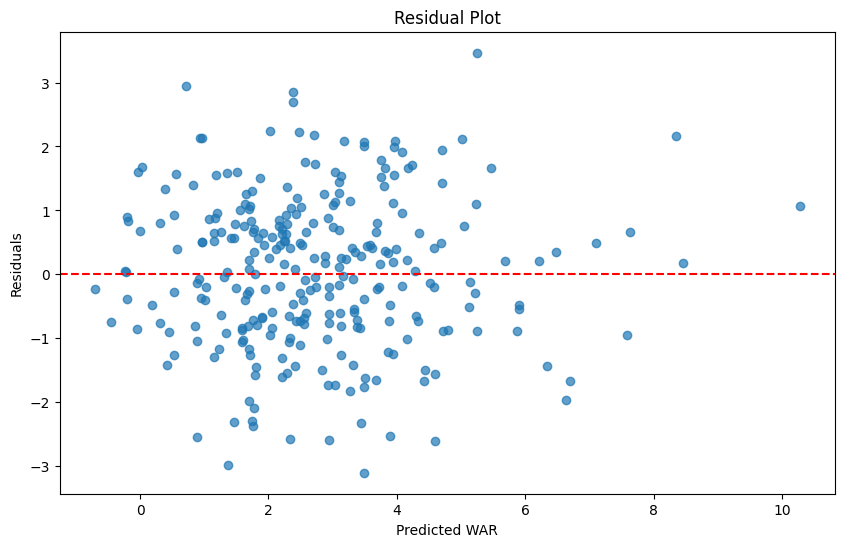

In [83]:
# residual plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted WAR')
plt.ylabel('Residuals')
plt.show()

In [69]:
# using the linear model to predict WAR for each player in the dataset
df['Predicted_WAR'] = model.predict(x)
df[['Name', 'Season', 'WAR', 'Predicted_WAR']].head(20)

,Name,Season,WAR,Predicted_WAR
0,Oneil Cruz,2025,1.580288,3.177515
1,Giancarlo Stanton,2017,6.434607,3.991643
2,Giancarlo Stanton,2021,3.050541,2.914591
3,Giancarlo Stanton,2018,3.772407,3.482830
4,Oneil Cruz,2024,3.603457,4.898203
5,Ronald Acuña Jr.,2023,9.154090,8.588907
6,Aaron Judge,2017,8.695028,8.685791
7,Vladimir Guerrero Jr.,2025,3.887598,4.772930
8,Shohei Ohtani,2025,7.480309,8.395483
9,Manny Machado,2021,4.476650,5.208905


In [70]:
# identifying players with the largest prediction errors
df['Prediction_Error'] = df['WAR'] - df['Predicted_WAR']
df['Absolute_Error'] = df['Prediction_Error'].abs()
top_errors = df.sort_values('Absolute_Error', ascending=False).head(10)
print(top_errors[['Name', 'Season', 'WAR', 'Predicted_WAR', 'Prediction_Error']])

                  Name  Season       WAR  Predicted_WAR  Prediction_Error
214        Cal Raleigh    2025  9.059341       5.058904          4.000436
382      Robinson Canó    2016  6.392560       2.713832          3.678728
1457        Nick Ahmed    2018  4.039529       0.377083          3.662446
224   Francisco Lindor    2018  7.797905       4.208219          3.589686
346     Josh Donaldson    2015  8.710970       5.172044          3.538926
1399      Alex Bregman    2019  8.326162       4.860474          3.465688
93       Carlos Correa    2021  6.287862       3.001954          3.285908
705     Russell Martin    2015  4.467947       1.211134          3.256813
443   Gunnar Henderson    2024  7.901268       4.678216          3.223052
1267        Adam Eaton    2016  6.216815       3.022978          3.193836


In [71]:
# identifying players over their careers with the largest cumulative prediction errors
career_errors = df.groupby('Name')['Prediction_Error'].sum().abs().sort_values(ascending=False).head(10)
print(career_errors)

Name
Francisco Lindor     18.383106
Nolan Arenado        13.466824
Nick Castellanos     13.298530
Eugenio Suárez       12.109738
Charlie Blackmon     11.921459
Andrew Benintendi    11.141313
Alex Bregman         10.403983
Cal Raleigh           9.157217
Willy Adames          8.693493
Manny Machado         8.474956
Name: Prediction_Error, dtype: float64


In [72]:
# finding players with the largest positive and negative predicition errors over their careers
career_errors_signed = df.groupby('Name')['Prediction_Error'].sum().sort_values()
print("Top 10 Players with Largest Positive Cumulative Prediction Errors:")
print(career_errors_signed.tail(10))
print("\nTop 10 Players with Largest Negative Cumulative Prediction Errors:")
print(career_errors_signed.head(10))

Top 10 Players with Largest Positive Cumulative Prediction Errors:
Name
Brandon Crawford     7.438730
Matt Chapman         7.694081
Jonathan Schoop      7.926991
Manny Machado        8.474956
Willy Adames         8.693493
Cal Raleigh          9.157217
Alex Bregman        10.403983
Eugenio Suárez      12.109738
Nolan Arenado       13.466824
Francisco Lindor    18.383106
Name: Prediction_Error, dtype: float64

Top 10 Players with Largest Negative Cumulative Prediction Errors:
Name
Nick Castellanos    -13.298530
Charlie Blackmon    -11.921459
Andrew Benintendi   -11.141313
Andrew McCutchen     -7.799683
Carlos Santana       -7.732518
Josh Bell            -7.364801
Albert Pujols        -7.221888
Luis Arraez          -6.245380
J.D. Martinez        -6.100787
Shin-Soo Choo        -5.848174
Name: Prediction_Error, dtype: float64
